# MNIST Dataset Training Setup using NVIDIA Docker and PyTorch

## Imports & GPU Verification

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

# Verifiy PyTorch sees the NVIDIA GPU inside th container
IS_CUDA = torch.cuda.is_available()
print(f"CUDA Available: {IS_CUDA}")
print(f"Current Device: {torch.cuda.get_device_name(0) if IS_CUDA else 'CPU'}")
device = torch.device("cuda" if IS_CUDA else "cpu")

CUDA Available: True
Current Device: NVIDIA GeForce RTX 3090


## Model Definition

This section defines the neural network architecture for the MNIST dataset.

In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

## Training and Testing Functions

These functions define the training and testing steps for each epoch.

In [3]:
def train(args, model, device, train_loader, optimizer, epoch):
    model.train()
    total_loss = 0
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
        correct += pred.eq(target.view_as(pred)).sum().item()
        loss.backward()
        optimizer.step()
        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if args.dry_run:
                break
    train_accuracy = 100. * correct / len(train_loader.dataset)
    return total_loss / len(train_loader), train_accuracy

def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        accuracy))
    return test_loss, accuracy

## Hyperparameters and Data Loading

This section sets up the training hyperparameters and loads the MNIST dataset.

In [4]:
class Args:
    def __init__(self):
        self.batch_size = 64
        self.test_batch_size = 1000
        self.epochs = 14
        self.lr = 1.0
        self.gamma = 0.7
        self.no_cuda = not IS_CUDA
        self.dry_run = False
        self.seed = 1
        self.log_interval = 10
        self.save_model = False
        self.train_losses = []
        self.test_losses = []
        self.train_accuracies = []
        self.test_accuracies = []

args = Args()

torch.manual_seed(args.seed)

train_kwargs = {'batch_size': args.batch_size}
test_kwargs = {'batch_size': args.test_batch_size}

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])
dataset1 = datasets.MNIST('../data', train=True, download=True,
                   transform=transform)
dataset2 = datasets.MNIST('../data', train=False,
                   transform=transform)
train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

model = Net().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)

## Training Loop with Validation

This section runs the training loop, including validation and model saving.

In [5]:
for epoch in range(1, args.epochs + 1):
    train_loss, train_accuracy = train(args, model, device, train_loader, optimizer, epoch)
    test_loss, test_accuracy = test(model, device, test_loader)
    scheduler.step()
    args.train_losses.append(train_loss)
    args.train_accuracies.append(train_accuracy)
    args.test_losses.append(test_loss)
    args.test_accuracies.append(test_accuracy)

if args.save_model:
    torch.save(model.state_dict(), "mnist_cnn.pt")

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.304465
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.277575
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.831688
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.526239
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.541902
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.259040
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.263783


Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.353359
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.446649
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.210294
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.352920
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.185796
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.334441
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.167945


Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.244278
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.111822
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.275131
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.150607
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.302181
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.225552
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.101401


Train Epoch: 1 [13440/60000 (22%)]	Loss: 0.123342
Train Epoch: 1 [14080/60000 (23%)]	Loss: 0.138339
Train Epoch: 1 [14720/60000 (25%)]	Loss: 0.330836
Train Epoch: 1 [15360/60000 (26%)]	Loss: 0.156072
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.185844
Train Epoch: 1 [16640/60000 (28%)]	Loss: 0.109632
Train Epoch: 1 [17280/60000 (29%)]	Loss: 0.112023


Train Epoch: 1 [17920/60000 (30%)]	Loss: 0.124617
Train Epoch: 1 [18560/60000 (31%)]	Loss: 0.280531
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.319016
Train Epoch: 1 [19840/60000 (33%)]	Loss: 0.105750
Train Epoch: 1 [20480/60000 (34%)]	Loss: 0.069011
Train Epoch: 1 [21120/60000 (35%)]	Loss: 0.271396
Train Epoch: 1 [21760/60000 (36%)]	Loss: 0.021298


...

Train Epoch: 14 [44800/60000 (75%)]	Loss: 0.070736
Train Epoch: 14 [45440/60000 (76%)]	Loss: 0.023991
Train Epoch: 14 [46080/60000 (77%)]	Loss: 0.023384
Train Epoch: 14 [46720/60000 (78%)]	Loss: 0.074817
Train Epoch: 14 [47360/60000 (79%)]	Loss: 0.030652
Train Epoch: 14 [48000/60000 (80%)]	Loss: 0.004082
Train Epoch: 14 [48640/60000 (81%)]	Loss: 0.001937


Train Epoch: 14 [49280/60000 (82%)]	Loss: 0.005700
Train Epoch: 14 [49920/60000 (83%)]	Loss: 0.056606
Train Epoch: 14 [50560/60000 (84%)]	Loss: 0.034505
Train Epoch: 14 [51200/60000 (85%)]	Loss: 0.052276
Train Epoch: 14 [51840/60000 (86%)]	Loss: 0.002865
Train Epoch: 14 [52480/60000 (87%)]	Loss: 0.022101
Train Epoch: 14 [53120/60000 (88%)]	Loss: 0.001698


Train Epoch: 14 [53760/60000 (90%)]	Loss: 0.078160
Train Epoch: 14 [54400/60000 (91%)]	Loss: 0.026384
Train Epoch: 14 [55040/60000 (92%)]	Loss: 0.045206
Train Epoch: 14 [55680/60000 (93%)]	Loss: 0.017573
Train Epoch: 14 [56320/60000 (94%)]	Loss: 0.001540
Train Epoch: 14 [56960/60000 (95%)]	Loss: 0.003081
Train Epoch: 14 [57600/60000 (96%)]	Loss: 0.044211


Train Epoch: 14 [58240/60000 (97%)]	Loss: 0.007851
Train Epoch: 14 [58880/60000 (98%)]	Loss: 0.032974
Train Epoch: 14 [59520/60000 (99%)]	Loss: 0.002090



Test set: Average loss: 0.0253, Accuracy: 9918/10000 (99%)



## Visualization of the Training Process

This section plots the training and validation loss and accuracy curves over the epochs to visualize the model's learning progress.

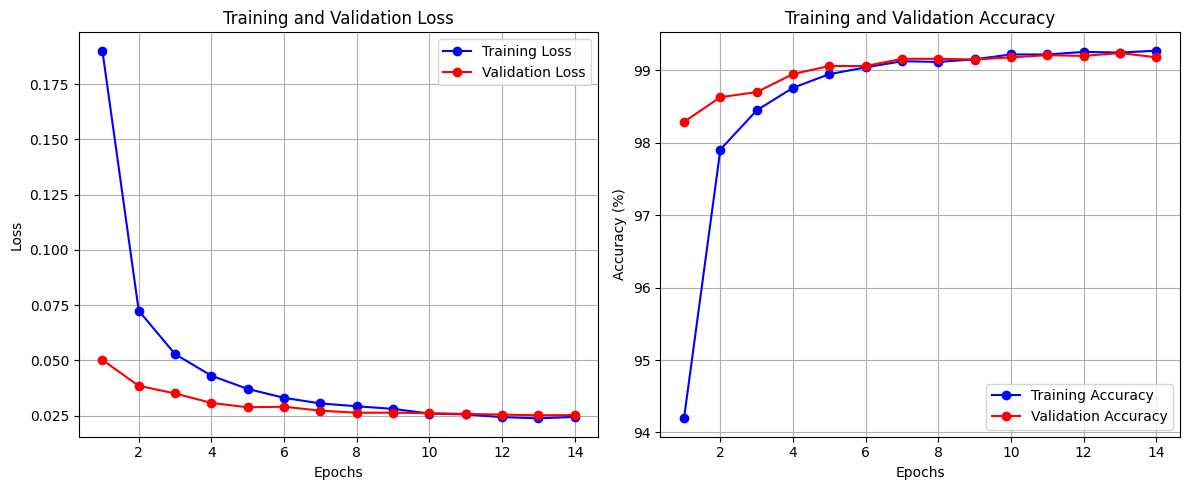

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(args.train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, args.train_losses, 'bo-', label='Training Loss')
plt.plot(epochs, args.test_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, args.train_accuracies, 'bo-', label='Training Accuracy')
plt.plot(epochs, args.test_accuracies, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Training Results Summary

Below is a structured summary of the key performance metrics achieved during the training process.

In [7]:
# Summary of Training Results
best_val_idx = args.test_accuracies.index(max(args.test_accuracies))
best_epoch = best_val_idx + 1

print("="*50)
print("TRAINING PROCESS SUMMARY")
print("="*50)
print(f"Total Epochs trained: {len(args.train_losses)}")
print(f"Final Training Loss:  {args.train_losses[-1]:.4f}")
print(f"Final Training Acc:   {args.train_accuracies[-1]:.2f}%")
print(f"Final Validation Loss: {args.test_losses[-1]:.4f}")
print(f"Final Validation Acc:  {args.test_accuracies[-1]:.2f}%")
print("-"*50)
print(f"Best Validation Acc:   {args.test_accuracies[best_val_idx]:.2f}% (Epoch {best_epoch})")
print(f"Corresponding Loss:   {args.test_losses[best_val_idx]:.4f}")
print("="*50)

TRAINING PROCESS SUMMARY
Total Epochs trained: 14
Final Training Loss:  0.0245
Final Training Acc:   99.27%
Final Validation Loss: 0.0253
Final Validation Acc:  99.18%
--------------------------------------------------
Best Validation Acc:   99.24% (Epoch 13)
Corresponding Loss:   0.0252
